# Breakout - DQN Reinforcement Learning 🧱

## 1. Imports
Libraries for the Atari environment (Gymnasium + ALE), neural network (PyTorch), and utilities.

In [12]:
import gymnasium as gym
import ale_py
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque

gym.register_envs(ale_py)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## 2. Environment
Load the Breakout Atari game using RAM observations (128 bytes). The AutoFire wrapper automatically presses FIRE to launch the ball after each life loss, so the agent focuses on playing.

In [13]:
class AutoFireWrapper(gym.Wrapper):
    def __init__(self, env):
        super().__init__(env)
        self.lives = 0

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        self.lives = info.get("lives", 5)
        obs, _, _, _, info = self.env.step(1)
        return obs, info

    def step(self, action):
        obs, reward, term, trunc, info = self.env.step(action)
        current_lives = info.get("lives", 0)
        if current_lives < self.lives and not term:
            obs, _, _, _, info = self.env.step(1)
        self.lives = current_lives
        return obs, reward, term, trunc, info

env = AutoFireWrapper(gym.make("ALE/Breakout-v5", obs_type="ram"))
print(f"Observation: {env.observation_space}")
print(f"Actions: {env.action_space}")
env.close()

Observation: Box(0, 255, (128,), uint8)
Actions: Discrete(4)


## 3. Replay Buffer
Stores transitions (state, action, reward, next_state, done) and samples random batches to break temporal correlation.

In [14]:
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def add(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (np.array(states), np.array(actions),
                np.array(rewards, dtype=np.float32),
                np.array(next_states),
                np.array(dones, dtype=np.float32))

    def __len__(self):
        return len(self.buffer)

## 4. Build Model
MLP neural network that takes the RAM state (128 values) and outputs Q-values for each possible action.

In [15]:
class QNetwork(nn.Module):
    def __init__(self, input_size, n_actions):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, n_actions)
        )

    def forward(self, x):
        return self.network(x)

## 5. Agent
DQN agent with epsilon-greedy exploration, experience replay, and a target network for stable training.

In [16]:
class DQNAgent:
    def __init__(self, input_size, n_actions, lr, gamma, epsilon, epsilon_min,
                 epsilon_decay, buffer_size, batch_size, target_update):
        self.n_actions = n_actions
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.batch_size = batch_size
        self.target_update = target_update
        self.steps = 0

        self.q_net = QNetwork(input_size, n_actions).to(device)
        self.target_net = QNetwork(input_size, n_actions).to(device)
        self.target_net.load_state_dict(self.q_net.state_dict())

        self.optimizer = optim.Adam(self.q_net.parameters(), lr=lr)
        self.loss_fn = nn.SmoothL1Loss()
        self.memory = ReplayBuffer(buffer_size)

    def select_action(self, state):
        if random.random() < self.epsilon:
            return random.randint(0, self.n_actions - 1)
        with torch.no_grad():
            state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
            return self.q_net(state_t).argmax().item()

    def train_step(self):
        if len(self.memory) < self.batch_size:
            return 0.0

        states, actions, rewards, next_states, dones = self.memory.sample(self.batch_size)

        s = torch.FloatTensor(states).to(device)
        a = torch.LongTensor(actions).to(device)
        r = torch.FloatTensor(rewards).to(device)
        s2 = torch.FloatTensor(next_states).to(device)
        d = torch.FloatTensor(dones).to(device)

        q_values = self.q_net(s).gather(1, a.unsqueeze(1)).squeeze(1)

        with torch.no_grad():
            q_target = r + (1 - d) * self.gamma * self.target_net(s2).max(1)[0]

        loss = self.loss_fn(q_values, q_target)
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.q_net.parameters(), 1.0)
        self.optimizer.step()

        self.steps += 1
        if self.steps % self.target_update == 0:
            self.target_net.load_state_dict(self.q_net.state_dict())

        return loss.item()

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

## 6. Hyperparameters
All configurable training parameters. Modify this cell and re-run to experiment.

In [17]:
N_EPISODES    = 3000
MAX_STEPS     = 10000
LR            = 0.0001
GAMMA         = 0.99
EPSILON_START = 1.0
EPSILON_MIN   = 0.02
EPSILON_DECAY = 0.998
BUFFER_SIZE   = 100000
BATCH_SIZE    = 64
TARGET_UPDATE = 1000
MODEL_PATH    = "modelos/breakout_v2.pth"

## 7. Training
Main training loop: the agent plays episodes, stores experiences, and updates the Q-network using the Bellman equation.

In [ ]:
env = AutoFireWrapper(gym.make("ALE/Breakout-v5", obs_type="ram"))
input_size = env.observation_space.shape[0]
n_actions = env.action_space.n

agent = DQNAgent(input_size, n_actions, LR, GAMMA, EPSILON_START,
                 EPSILON_MIN, EPSILON_DECAY, BUFFER_SIZE, BATCH_SIZE, TARGET_UPDATE)

reward_history = []
loss_history = []
best_reward = -float('inf')

for ep in range(N_EPISODES):
    state, _ = env.reset()
    state = state / 255.0
    total_reward = 0
    total_loss = 0
    n_updates = 0

    for step in range(MAX_STEPS):
        action = agent.select_action(state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        next_state = next_state / 255.0
        done = terminated or truncated

        agent.memory.add(state, action, reward, next_state, done)
        loss = agent.train_step()
        if loss > 0:
            total_loss += loss
            n_updates += 1

        total_reward += reward
        state = next_state
        if done:
            break

    agent.decay_epsilon()
    reward_history.append(total_reward)
    loss_history.append(total_loss / max(n_updates, 1))

    if total_reward > best_reward:
        best_reward = total_reward
        torch.save(agent.q_net.state_dict(), MODEL_PATH)

    if (ep + 1) % 50 == 0:
        avg = np.mean(reward_history[-50:])
        print(f"Ep {ep+1:4d}/{N_EPISODES} | Rew: {total_reward:6.0f} | "
              f"Avg(50): {avg:7.1f} | Best: {best_reward:6.0f} | "
              f"Eps: {agent.epsilon:.4f}")

env.close()
print(f"\nDone! Best: {best_reward} | Model: {MODEL_PATH}")

Ep   50/3000 | Rew:      1 | Avg(50):     1.2 | Best:      4 | Eps: 0.9047
Ep  100/3000 | Rew:      2 | Avg(50):     1.3 | Best:      4 | Eps: 0.8186
Ep  150/3000 | Rew:      3 | Avg(50):     3.0 | Best:      9 | Eps: 0.7406
Ep  200/3000 | Rew:      3 | Avg(50):     4.4 | Best:     11 | Eps: 0.6701


## 8. Results
Plot the learning curve (reward per episode) and training loss over time.

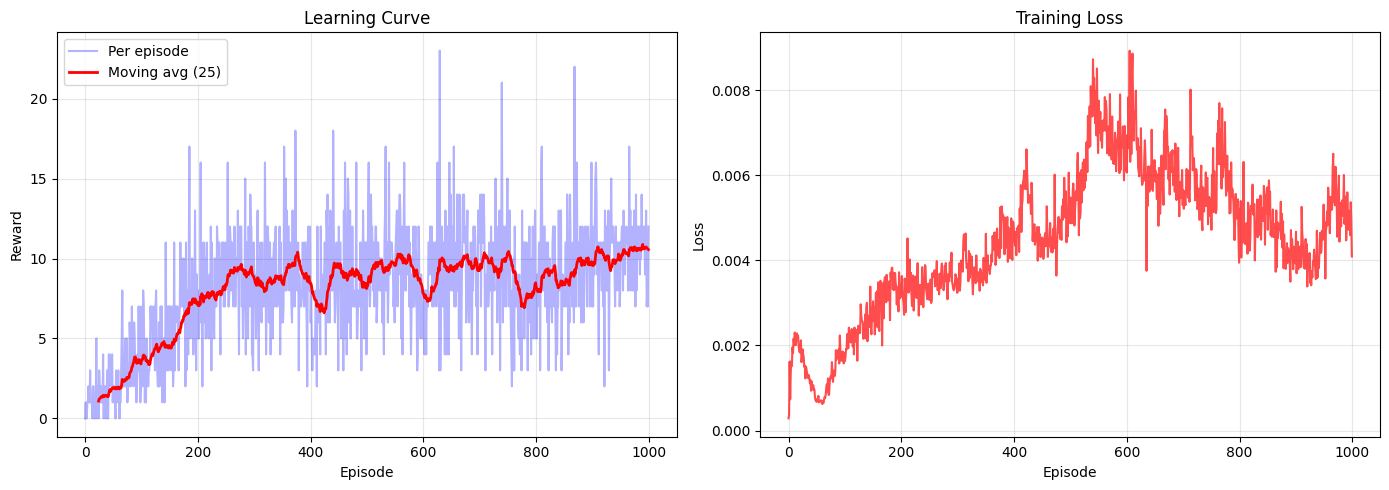

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

w = 25
axes[0].plot(reward_history, alpha=0.3, color='blue', label='Per episode')
if len(reward_history) >= w:
    avg = np.convolve(reward_history, np.ones(w)/w, mode='valid')
    axes[0].plot(range(w-1, len(reward_history)), avg, 'r-', lw=2, label=f'Moving avg ({w})')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Reward')
axes[0].set_title('Learning Curve')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(loss_history, alpha=0.7, color='red')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Loss')
axes[1].set_title('Training Loss')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(MODEL_PATH.replace('.pth', '.png'), dpi=150)
plt.show()

## 9. Save & Evaluate
Load the best model and test it over 10 games with no exploration (epsilon = 0).

In [ ]:
agent.q_net.load_state_dict(torch.load(MODEL_PATH, weights_only=True))
agent.epsilon = 0
print(f"Model loaded: {MODEL_PATH}")

env_eval = AutoFireWrapper(gym.make("ALE/Breakout-v5", obs_type="ram"))
eval_rewards = []

for ep in range(10):
    state, _ = env_eval.reset()
    state = state / 255.0
    total = 0
    for _ in range(MAX_STEPS):
        action = agent.select_action(state)
        next_s, reward, term, trunc, _ = env_eval.step(action)
        total += reward
        state = next_s / 255.0
        if term or trunc:
            break
    eval_rewards.append(total)
    print(f"  Game {ep+1:2d}: {total:.0f}")

env_eval.close()
print(f"\nAvg: {np.mean(eval_rewards):.1f} | Std: {np.std(eval_rewards):.1f} | "
      f"Best: {np.max(eval_rewards):.0f} | Worst: {np.min(eval_rewards):.0f}")

## 10. Watch it play
Record a game as a GIF to visually see how the trained agent plays Breakout.

In [ ]:
from PIL import Image
from IPython.display import Image as IPImage, display

agent.q_net.load_state_dict(torch.load(MODEL_PATH, weights_only=True))
agent.epsilon = 0

env_vis = AutoFireWrapper(gym.make("ALE/Breakout-v5", obs_type="ram", render_mode="rgb_array"))
frames = []
state, _ = env_vis.reset()
frames.append(env_vis.render())
state = state / 255.0

for _ in range(3000):
    action = agent.select_action(state)
    next_s, reward, term, trunc, _ = env_vis.step(action)
    frames.append(env_vis.render())
    state = next_s / 255.0
    if term or trunc:
        break

env_vis.close()

gif_path = MODEL_PATH.replace('.pth', '.gif')
frames_pil = [Image.fromarray(f) for f in frames[::3]]
frames_pil[0].save(gif_path, save_all=True, append_images=frames_pil[1:], duration=50, loop=0)
print(f"GIF saved: {gif_path} ({len(frames_pil)} frames)")
display(IPImage(filename=gif_path))